# 01 — Preparación del Dataset

Clasificación multi-label de patologías en radiografías de tórax.  
Datasets: **ChestXray8** (NIH) · **CheXpert** (Stanford) · **VinBigData** (Kaggle)

Este notebook cubre:
- **(a)** Clase `Dataset` de PyTorch y `DataLoader`
- **(b)** Particionado train / val / test
- **(c)** Preprocesamiento
- **(d)** Data augmentation
- **(e)** Verificación final del batch

## Setup

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Semilla global para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Directorio raíz del dataset (contiene ChestXray8/, chexpert/, VinBigData/)
DATASET_ROOT = os.path.abspath(os.path.join(".."))
DATA_DIR     = os.path.join(DATASET_ROOT, "data")

print(f"PyTorch:      {torch.__version__}")
print(f"torchvision:  {torchvision.__version__}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Data dir:     {DATA_DIR}")
assert os.path.exists(DATA_DIR), f"No se encuentra data/: {DATA_DIR}"

PyTorch:      2.12.0+cpu
torchvision:  0.27.0+cpu
Dataset root: e:\dataset
Data dir:     e:\dataset\data


## Labels canónicos

In [2]:
CANONICAL_LABELS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Pleural_Effusion", "Pneumonia", "Pneumothorax",
    "Infiltration", "Nodule_Mass", "Pleural_Thickening", "No_Finding",
]
NUM_CLASSES = len(CANONICAL_LABELS)
print(f"{NUM_CLASSES} clases:", CANONICAL_LABELS)

11 clases: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural_Effusion', 'Pneumonia', 'Pneumothorax', 'Infiltration', 'Nodule_Mass', 'Pleural_Thickening', 'No_Finding']


## (a) Clase Dataset

`ChestXRayDataset` hereda de `torch.utils.data.Dataset` e implementa los tres métodos requeridos:
- `__init__`: lee el CSV y guarda la ruta raíz
- `__len__`: retorna la cantidad de muestras
- `__getitem__`: carga la imagen, convierte a RGB (los chest X-rays son grayscale; DenseNet121 espera 3 canales), y construye el tensor de labels

Los labels `NaN` se rellenan con `0.0` (tratados como negativos). Esto simplifica el entrenamiento; una alternativa más correcta sería usar una loss enmascarada que ignore las posiciones `NaN`.

In [3]:
class ChestXRayDataset(Dataset):
    def __init__(self, csv_path, root_dir, labels=CANONICAL_LABELS, transform=None, nan_fill=0.0):
        self.df        = pd.read_csv(csv_path)
        self.root_dir  = root_dir
        self.labels    = labels
        self.transform = transform
        self.nan_fill  = nan_fill

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image_path"])
        img      = Image.open(img_path).convert("RGB")
        label_vals = row[self.labels].fillna(self.nan_fill).values.astype("float32")
        labels   = torch.tensor(label_vals)
        if self.transform:
            img = self.transform(img)
        return img, labels

print("Clase ChestXRayDataset definida.")

Clase ChestXRayDataset definida.


## (c) Preprocesamiento

Se usa un modelo preentrenado en ImageNet (DenseNet121) que espera:
- Imágenes de **224×224** píxeles
- 3 canales RGB
- Normalización con `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]`

Para **val** y **test** no hay augmentation — solo resize + normalización.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transform val/test definido.")

Transform val/test definido.


## (d) Data Augmentation (solo train)

Las augmentations se eligen considerando las características de las radiografías de tórax:

| Transformación | Por qué tiene sentido |
|---|---|
| `RandomCrop(224)` desde resize 256 | Pequeñas variaciones de encuadre, igual al protocolo ResNet original |
| `RandomHorizontalFlip(p=0.5)` | El corazón es levemente asimétrico pero la flip es aceptada en la literatura clínica |
| `RandomRotation(±10°)` | Simula variaciones en el posicionamiento del paciente |
| `ColorJitter(brightness, contrast)` | Simula variaciones en la configuración del equipo de rayos X |

**NO** se aplica: flip vertical (anatomía incorrecta), zoom agresivo (recorta pulmones), ni distorsiones geométricas fuertes.

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transform train con augmentation definido.")

Transform train con augmentation definido.


### Visualización del efecto de las augmentations

Se toman 4 imágenes del set de train y se muestran 4 versiones aumentadas de cada una. Las augmentations **NO incluyen la normalización** para que las imágenes sean visualmente interpretables.

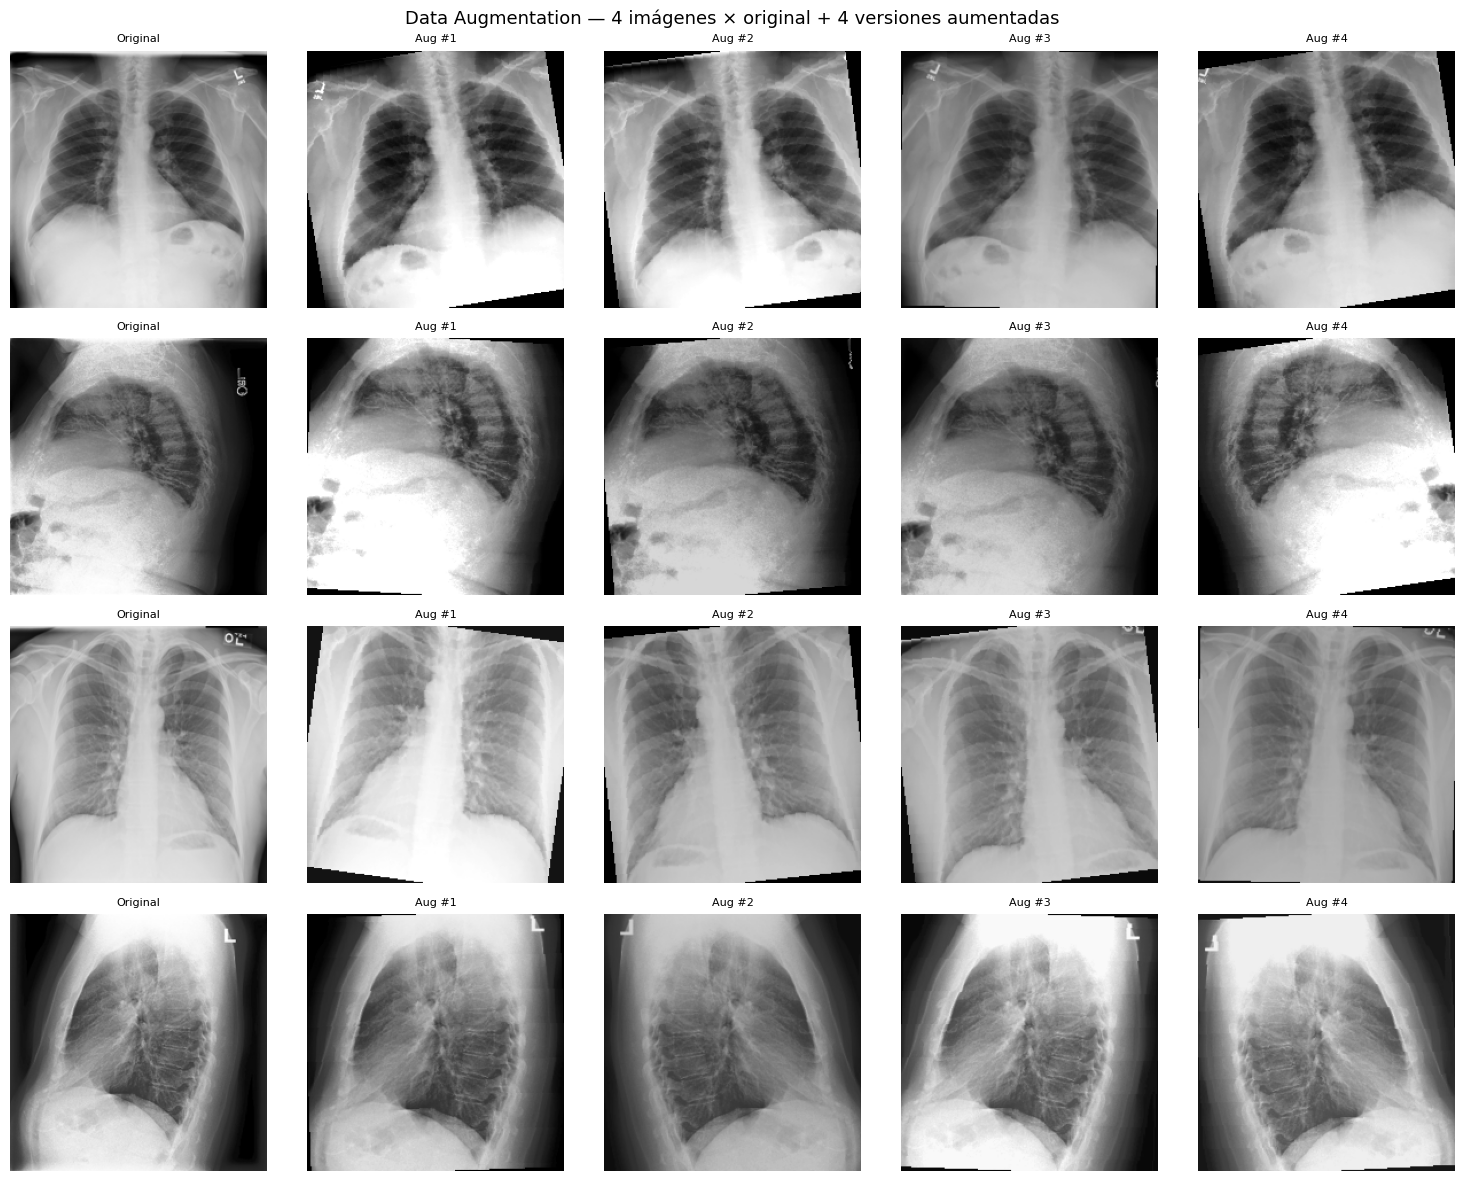

In [6]:
# Transform solo para visualización (sin normalización)
aug_vis_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

train_csv = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
sample_rows = train_csv.sample(4, random_state=SEED)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle("Data Augmentation — 4 imágenes × original + 4 versiones aumentadas", fontsize=13)

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    img_path = os.path.join(DATASET_ROOT, row["image_path"])
    original = Image.open(img_path).convert("RGB").resize((224, 224))

    axes[row_idx, 0].imshow(original, cmap="gray")
    axes[row_idx, 0].set_title("Original", fontsize=8)
    axes[row_idx, 0].axis("off")

    active = [l for l in CANONICAL_LABELS if row[l] == 1.0]
    label_str = ", ".join(active) if active else "No Finding"
    axes[row_idx, 0].set_xlabel(label_str, fontsize=6, wrap=True)

    for aug_idx in range(1, 5):
        augmented = aug_vis_transform(Image.open(img_path).convert("RGB"))
        axes[row_idx, aug_idx].imshow(augmented, cmap="gray")
        axes[row_idx, aug_idx].set_title(f"Aug #{aug_idx}", fontsize=8)
        axes[row_idx, aug_idx].axis("off")

plt.tight_layout()
plt.show()

## (a) DataLoaders

In [ ]:
BATCH_SIZE  = 32
NUM_WORKERS = 0

train_ds = ChestXRayDataset(
    csv_path  = os.path.join(DATA_DIR, "train.csv"),
    root_dir  = DATASET_ROOT,
    transform = train_transform,
)
val_ds = ChestXRayDataset(
    csv_path  = os.path.join(DATA_DIR, "val.csv"),
    root_dir  = DATASET_ROOT,
    transform = val_test_transform,
)
test_ds = ChestXRayDataset(
    csv_path  = os.path.join(DATA_DIR, "test.csv"),
    root_dir  = DATASET_ROOT,
    transform = val_test_transform,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"train_ds: {len(train_ds):,} imágenes")
print(f"val_ds:   {len(val_ds):,} imágenes")
print(f"test_ds:  {len(test_ds):,} imágenes")
print(f"\nbatch_size:  {BATCH_SIZE}")
print(f"num_workers: {NUM_WORKERS}")
print(f"shuffle train: True   |   shuffle val/test: False")

train_ds: 110,350 imágenes
val_ds:   203,024 imágenes
test_ds:  26,396 imágenes

batch_size:  32
num_workers: 2
shuffle train: True   |   shuffle val/test: False


## (b) Particionado

### Criterio de partición

| Dataset | Estrategia | Fuente |
|---|---|---|
| **ChestXray8** | Split oficial | `train_val_list.txt` → train/val, `test_list.txt` → test |
| **CheXpert** | Split oficial | `train.csv` → train/val, `valid.csv` → test |
| **VinBigData** | Aleatorio 80/20 | split por `image_id`, `random_state=42` |
| **Validación** | 15% de train | split por `image_id`, `random_state=42` |

El split se hace a nivel de `image_id` (no por fila) para evitar que distintas vistas del mismo estudio queden simultáneamente en train y val.

In [8]:
# Distribución por clase en cada partición
splits = {
    "train": pd.read_csv(os.path.join(DATA_DIR, "train.csv")),
    "val":   pd.read_csv(os.path.join(DATA_DIR, "val.csv")),
    "test":  pd.read_csv(os.path.join(DATA_DIR, "test.csv")),
}

print("=" * 60)
print(f"{'Split':<8} {'Total':>10}  {'ChestXray8':>12}  {'CheXpert':>10}  {'VinBig':>8}")
print("=" * 60)
for name, df in splits.items():
    vc = df["source"].value_counts()
    print(f"{name:<8} {len(df):>10,}  {vc.get('chestxray8',0):>12,}  {vc.get('chexpert',0):>10,}  {vc.get('vinbigdata',0):>8,}")

print("\nPositivos por label (train):")
pos_train = (splits["train"][CANONICAL_LABELS] == 1.0).sum()
total_train = len(splits["train"])
dist_table = pd.DataFrame({
    "positivos_train": pos_train,
    "% train":         (pos_train / total_train * 100).round(1),
    "positivos_val":   (splits["val"][CANONICAL_LABELS] == 1.0).sum(),
    "positivos_test":  (splits["test"][CANONICAL_LABELS] == 1.0).sum(),
})
print(dist_table.to_string())

Split         Total    ChestXray8    CheXpert    VinBig
train       110,350        73,533      34,082     2,735
val         203,024        12,991     189,566       467
test         26,396        25,596           0       800

Positivos por label (train):
                    positivos_train  % train  positivos_val  positivos_test
Atelectasis                   10871      9.9          30942            3302
Cardiomegaly                   6714      6.1          23772            1492
Consolidation                  4461      4.0          13347            1849
Edema                          4342      3.9          49327             925
Pleural_Effusion              17888     16.2          77675            4811
Pneumonia                      2113      1.9           4810             555
Pneumothorax                   4331      3.9          17821            2673
Infiltration                  12041     10.9           2077            6197
Nodule_Mass                    7329      6.6           1305   

## (e) Verificación final del batch

In [ ]:
imgs, labels = next(iter(train_loader))

print(f"Tensor imágenes : {imgs.shape}   (batch_size, canales, alto, ancho)")
print(f"Tensor labels   : {labels.shape}  (batch_size, num_clases)")
print(f"Rango de valores normalizados: [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"dtype imágenes  : {imgs.dtype}")
print(f"dtype labels    : {labels.dtype}")
print(f"Valores únicos en labels: {labels.unique().tolist()}")

e:\dataset\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# Desnormalizar y visualizar 8 imágenes del batch con sus labels
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

imgs_denorm = (imgs * std_t + mean_t).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Batch de train — imágenes desnormalizadas + labels activos", fontsize=12)

for i, ax in enumerate(axes.flat):
    # Convertir tensor a numpy y transponer (C, H, W) -> (H, W, C)
    img_np = imgs_denorm[i].permute(1, 2, 0).numpy()
    # Radiografías son en escala de grises; mostrar canal promedio
    ax.imshow(img_np.mean(axis=2), cmap="gray")

    active = [CANONICAL_LABELS[j] for j, v in enumerate(labels[i]) if v == 1.0]
    label_str = "\n".join(active) if active else "No Finding"
    ax.set_title(label_str, fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()
print("Verificación completa: pares imagen-etiqueta correctos.")